<a href="https://colab.research.google.com/github/AlbertoMoric/AI-BigData-Portfolio/blob/main/modelos-ia/regresion-prediccion/notebook/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***1. Entender los datos***

## ***1.1. Cargar dataset***

In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/portafolio/house-prices-advanced-regression-techniques/train.csv")
df.head(1)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500


## ***1.2. Entender estructura***

In [ ]:
df.shape

(1460, 81)

```
Análisis del tamaño del dataset
El conjunto de datos cuenta con 1460 registros y múltiples variables descriptivas.
Dado el tamaño del dataset, se optará por utilizar algoritmos de Machine Learning tradicionales, ya que son más adecuados para este volumen de datos. El uso de técnicas de Deep Learning no sería recomendable en este caso debido al riesgo de sobreajuste y a la necesidad de datasets de mayor tamaño para su correcto rendimiento.
```

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

```
Análisis de tipos de datos
El dataset está compuesto por variables numéricas (int y float) y variables categóricas (object).
Esta distribución es habitual en problemas de regresión y sugiere la necesidad de aplicar técnicas de preprocesamiento antes del entrenamiento de modelos de Machine Learning, especialmente la codificación de variables categóricas.
Los algoritmos de Machine Learning requieren que todas las variables de entrada sean numéricas, por lo que será necesario transformar las variables de tipo object en variables numéricas mediante técnicas como One-Hot Encoding o Label Encoding.
```

## ***1.3. Estadísticas básicas***

In [ ]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


```
Estadística descriptiva
Mediante la función describe() se obtiene un resumen estadístico de las variables numéricas del dataset.
Este análisis permite conocer la distribución de los datos, incluyendo medidas como la media, desviación estándar, valores mínimos y máximos, así como los percentiles.
Esta información es útil para detectar posibles valores atípicos (outliers), diferencias de escala entre variables y comprender mejor la distribución general de los datos antes de aplicar modelos de Machine Learning.
```

## ***1.4. Valores nulos***

In [ ]:
df.isnull().sum().sort_values(ascending=False).head(2)

,0
PoolQC,1453
MiscFeature,1406


## ***1.5. Variable objetivo***

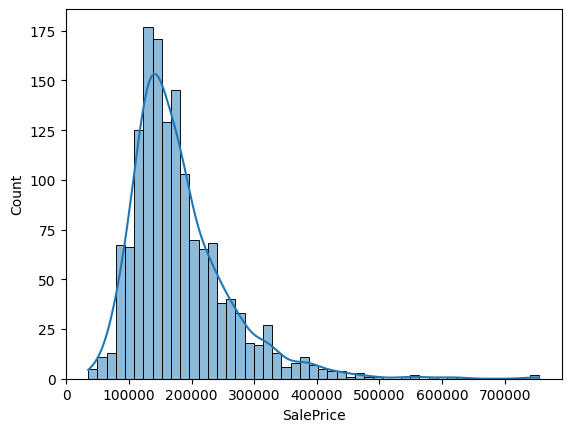

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["SalePrice"], kde=True)
plt.show()

## ***1.6. Correlación***

In [ ]:
corr = df.corr(numeric_only=True)
corr["SalePrice"].sort_values(ascending=False).head(3)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624


```
Análisis de correlación
Se ha realizado un análisis de correlación entre las variables numéricas del dataset para identificar aquellas con mayor relación con la variable objetivo (SalePrice).
Se han considerado especialmente las variables con una correlación superior a 0.7 en valor absoluto, ya que presentan una relación lineal más fuerte con el precio de la vivienda.
Este análisis se utiliza como guía exploratoria para entender las variables más influyentes, pero no como criterio definitivo de selección de características, ya que el modelo final puede beneficiarse de interacciones entre múltiples variables.
```

# ***2. Buscar conclusiones***

## ***2.1. Variables importantes***

In [ ]:
corr = df.corr(numeric_only=True)
top_features = corr["SalePrice"].sort_values(ascending=False).head(4)
top_features

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409


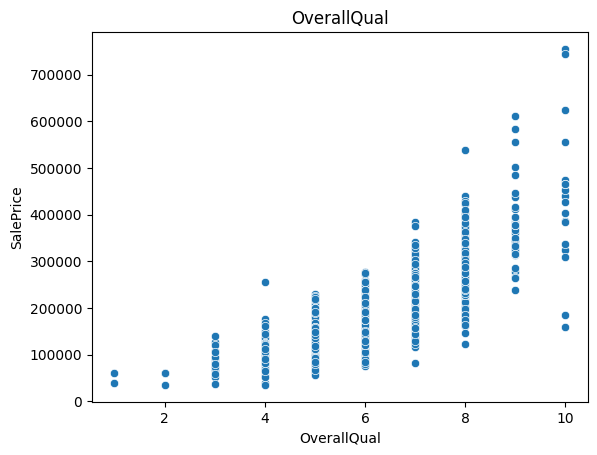

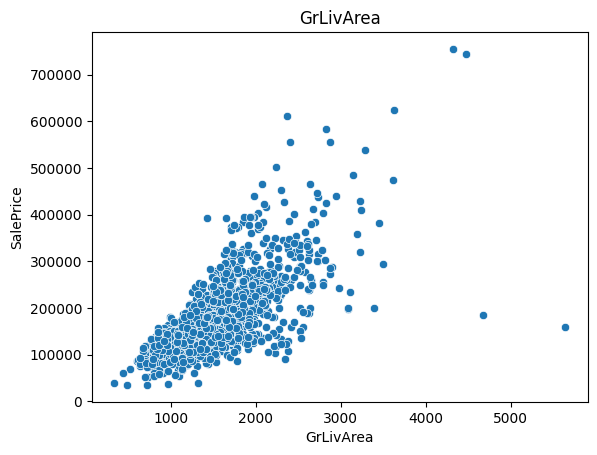

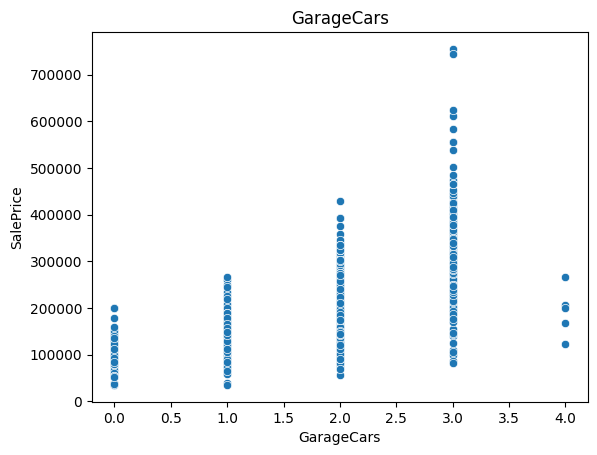

In [ ]:
important_features = ["OverallQual", "GrLivArea", "GarageCars"]

for feature in important_features:
    sns.scatterplot(x=df[feature], y=df["SalePrice"])
    plt.title(feature)
    plt.show()

## ***2.2. Detectar outliers***

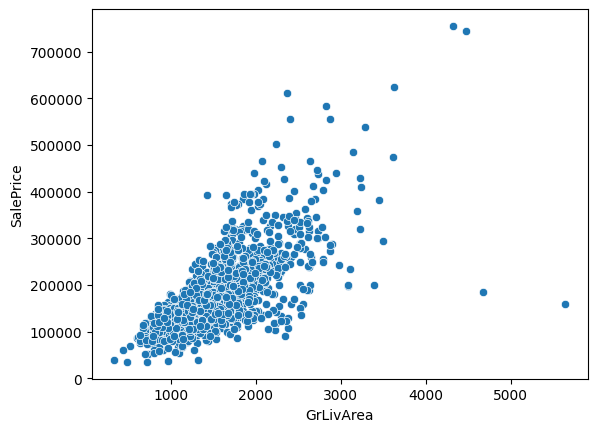

In [ ]:
sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"])
plt.show()

## ***2.3. Variables categóricas***

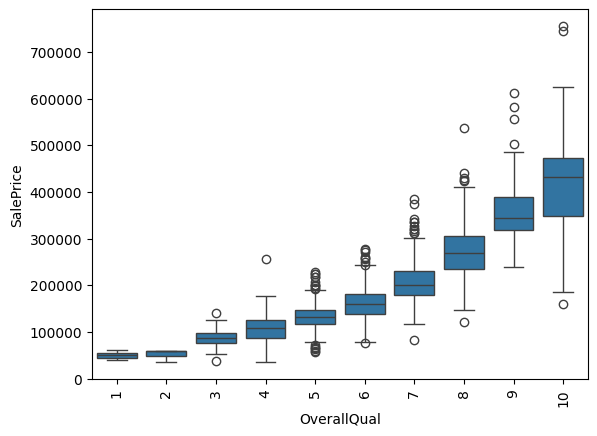

In [ ]:
sns.boxplot(x="OverallQual", y="SalePrice", data=df)
plt.xticks(rotation=90)
plt.show()

## ***2.4. variable objetivo***

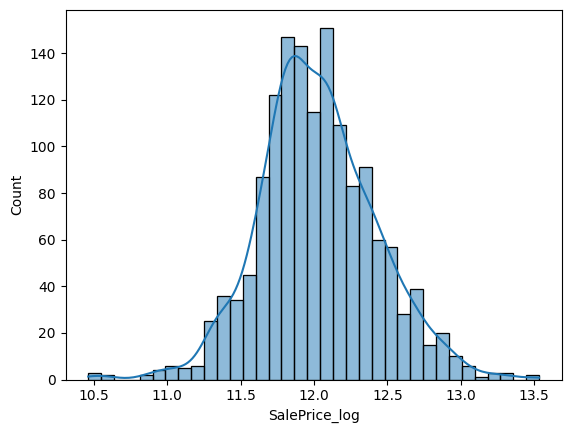

In [ ]:
import numpy as np

df["SalePrice_log"] = np.log(df["SalePrice"])
sns.histplot(df["SalePrice_log"], kde=True)
plt.show()

```
Transformación logarítmica de la variable objetivo
Se aplica una transformación logarítmica a la variable SalePrice debido a su distribución sesgada hacia la derecha.
Esta transformación ayuda a reducir el impacto de valores extremos, estabilizar la varianza y aproximar la distribución a una forma más normal, lo que mejora el rendimiento de los modelos de regresión.
Además, facilita el aprendizaje del modelo al trabajar con relaciones más lineales entre las variables.
```

## ***2.5. Conclusión***

```
Conclusiones del análisis exploratorio (EDA)
Tras el análisis exploratorio del dataset se han obtenido varias conclusiones relevantes:
- El dataset contiene un número adecuado de observaciones para aplicar técnicas de Machine Learning tradicionales.
- La variable objetivo (SalePrice) presenta una distribución sesgada hacia la derecha, por lo que se ha aplicado una transformación logarítmica para mejorar su comportamiento.
- Se han identificado variables con una fuerte correlación con el precio de la vivienda, como OverallQual y GrLivArea.
- Existen valores atípicos (outliers) en algunas variables que deberán ser tratados en fases posteriores del preprocesamiento.
- El dataset contiene variables categóricas que requerirán técnicas de codificación antes de su uso en modelos de Machine Learning.
```

# ***3. Limpieza de datos***

## ***3.1. Valores nulos***

In [ ]:
nulls = df.isnull().sum().sort_values(ascending=False)
nulls[nulls > 0]

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageYrBlt,81
GarageFinish,81


## ***3.2. Separar variables***

In [ ]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

## ***3.3. Tratamiento de variables numéricas***

In [ ]:
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_14848/3154000584.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


## ***3.4. Tratamiento de categóricas***

In [ ]:
for col in categorical_cols:
    df[col].fillna("None", inplace=True)

/tmp/ipykernel_14848/444036141.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna("None", inplace=True)


## ***3.5. Revisar outliers***

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

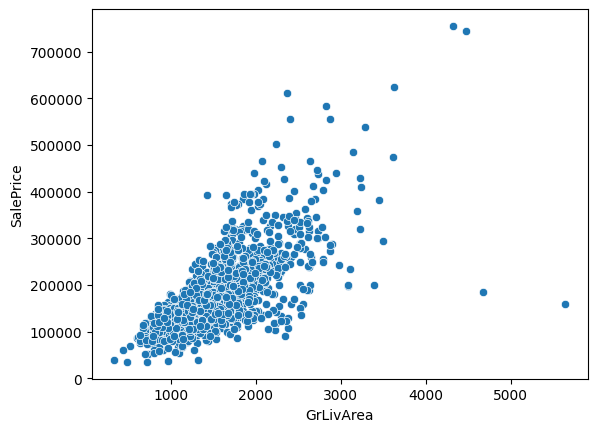

In [ ]:
import seaborn as sns
sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"])

In [ ]:
df = df[df["GrLivArea"] < 4000]

## ***3.6. Transformación de variables***

In [ ]:
df["SalePrice_log"] = np.log(df["SalePrice"])

## ***3.7. Verificación final***

In [ ]:
df.isnull().sum().sum()

np.int64(0)

```
Data Cleaning

En esta fase se ha realizado la limpieza y preparación del dataset para su uso en modelos de Machine Learning.

Se han tratado los valores nulos mediante imputación en variables numéricas utilizando la mediana, y sustitución por "None" en variables categóricas.

Además, se han analizado posibles valores atípicos y se han aplicado transformaciones en la variable objetivo para mejorar su distribución.
```

# ***4. Preparar dataframe***

## ***4.1. Definir el problema***

In [ ]:
y = df["SalePrice"]
X = df.drop("SalePrice", axis=1)

In [ ]:
y = df["SalePrice_log"]
X = df.drop(["SalePrice", "SalePrice_log"], axis=1)

## ***4.2. Separar variables***

In [ ]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

## ***4.3. Encoding categorica***

In [ ]:
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

## ***4.4. Verificar dataset final***

In [ ]:
X_encoded.shape

(1456, 260)

In [ ]:
X_encoded.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,True,False,False,False,True,False


## ***4.5. Verificar consistencia***

In [ ]:
X_encoded.isnull().sum().sum()

np.int64(0)

```
Preparación del dataset

Se ha realizado la separación entre variables predictoras (X) y variable objetivo (y).

Posteriormente, se han identificado variables categóricas y numéricas, aplicando técnicas de codificación (One-Hot Encoding) para transformar las variables categóricas en formato numérico.

El dataset resultante está completamente preparado para su uso en modelos de Machine Learning.
```

# ***5. Modelo ML***

## ***5.1. Train / Test***

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(1164, 260)
(292, 260)


## ***5.2. Primer modelo***

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## ***5.3. Hacer predicciones***

In [ ]:
y_pred = model.predict(X_test)

## ***5.4 Evaluar el modelo***

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.08837448830780045
RMSE: 0.13007125481954251


```
El modelo presenta un MAE de 0.088 y un RMSE de 0.130 en escala logarítmica.

Estos valores indican que el modelo es capaz de predecir el precio de las viviendas con un error relativamente bajo, especialmente considerando que se trata de un problema de regresión con múltiples variables.

El hecho de que el RMSE no sea significativamente mayor que el MAE sugiere que no existen errores extremos importantes, lo que indica un comportamiento estable del modelo.
```

# ***6. Mejorar modelo***

## ***6.1. Random forest***

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=1000,
    random_state=42
)

In [ ]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=1000, random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 0.10322467217325802
Random Forest RMSE: 0.14946707615497015


In [ ]:
print("Linear Regression RMSE:", rmse)
print("Random Forest RMSE:", rf_rmse)

Linear Regression RMSE: 0.13007125481954251
Random Forest RMSE: 0.14946707615497015


```
Comparación de modelos

Tras comparar los resultados obtenidos entre Regresión Lineal y Random Forest Regressor, se observa que el modelo de regresión lineal ofrece un mejor rendimiento en este dataset.

Aunque Random Forest es capaz de capturar relaciones no lineales complejas, en este caso el tamaño del dataset y la naturaleza de las variables favorecen un modelo más simple y generalizable.

Este resultado demuestra que modelos más complejos no siempre garantizan un mejor rendimiento, siendo fundamental evaluar cada algoritmo según el contexto del problema.
```

# ***7. Visualizar resultados***

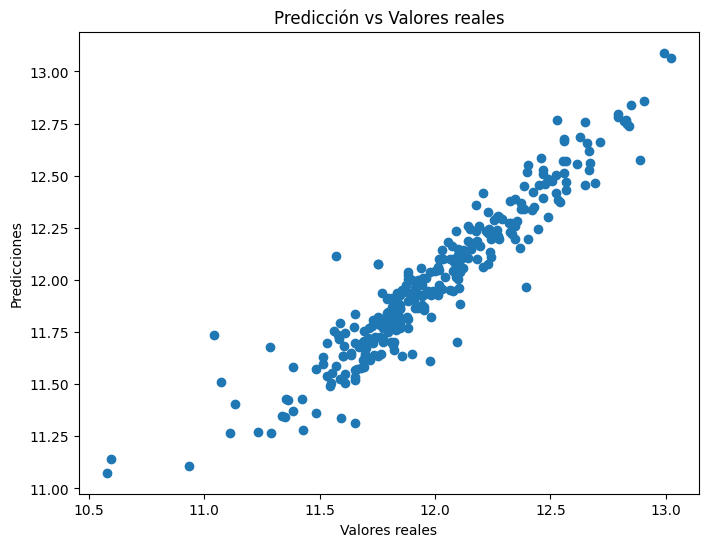

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Valores reales")
plt.ylabel("Predicciones")

plt.title("Predicción vs Valores reales")

plt.show()

In [ ]:
residuals = y_test - y_pred

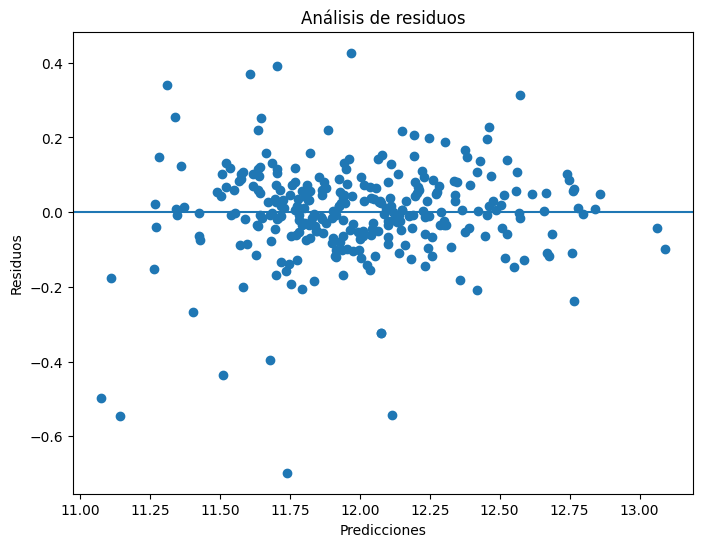

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicciones")
plt.ylabel("Residuos")

plt.title("Análisis de residuos")

plt.show()

In [ ]:
import pandas as pd

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
4,OverallQual,0.546253
16,GrLivArea,0.109620
27,GarageArea,0.055859
12,TotalBsmtSF,0.039130
9,BsmtFinSF1,0.031228
26,GarageCars,0.028686
13,1stFlrSF,0.018977
6,YearBuilt,0.017457
3,LotArea,0.010877
5,OverallCond,0.009061


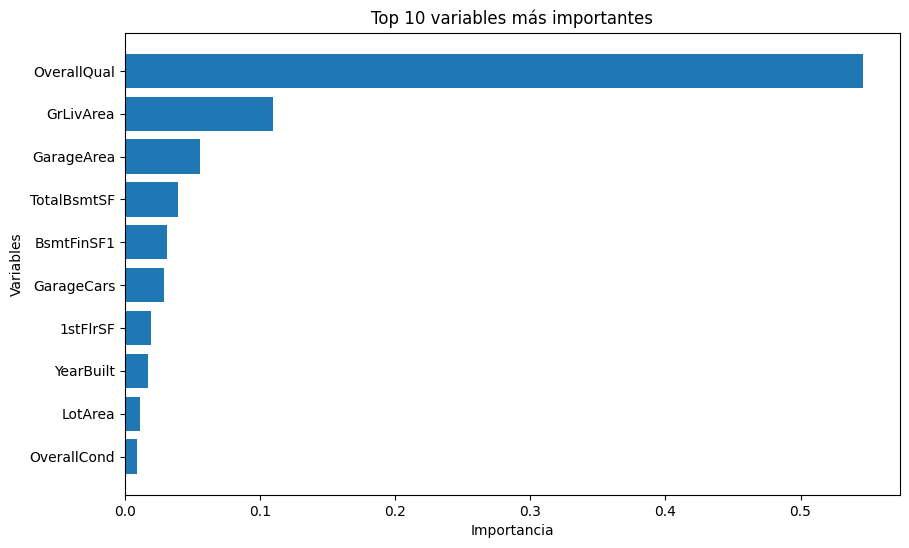

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top_features["Feature"], top_features["Importance"])

plt.xlabel("Importancia")
plt.ylabel("Variables")

plt.title("Top 10 variables más importantes")

plt.gca().invert_yaxis()

plt.show()